In [711]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from typing import Optional, Tuple, List
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.spatial import KDTree
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"


train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)

In [622]:
train = train.copy()

In [623]:
train.head(10)

,sensor,time,power,temperature
0,N102,0.0,1487.964722,17.514429
1,N102,864000.0,1487.288818,17.820795
2,N102,1728000.0,1486.612915,17.573187
3,N102,2592000.0,1485.936890,16.513235
4,N102,3456000.0,1485.260986,16.303427
5,N102,4320000.0,1484.585083,17.033432
6,N102,5184000.0,1483.909058,17.430515
7,N102,6048000.0,1483.233154,17.254442
8,N102,6912000.0,1482.557251,17.905001
9,N102,7776000.0,1481.881226,17.375288


In [624]:
train.shape

(6626928, 4)

In [625]:
#sensors.plot(kind='scatter', x='coor_x', y='coor_y')

In [626]:
#train.plot(kind='scatter', x='time', y='power')

In [627]:
#train.plot(kind='scatter', x='time', y='temperature', alpha=0.3)

In [628]:
#view of possible outliers --> here we see two 'bad' sensors
#train.plot(kind='scatter', x='sensor', y='temperature')

In [629]:
train.describe(include="all")

,sensor,time,power,temperature
count,6626928,6.626928e+06,6.626928e+06,6.527525e+06
unique,242,NaN,NaN,NaN
top,N102,NaN,NaN,NaN
freq,27384,NaN,NaN,NaN
mean,NaN,3.942130e+09,5.549463e+02,4.706070e+01
std,NaN,2.275997e+09,5.258427e+02,3.897674e+02
min,NaN,0.000000e+00,0.000000e+00,-2.921508e+02
25%,NaN,1.971605e+09,0.000000e+00,1.566275e+01
50%,NaN,3.942432e+09,4.445813e+02,1.939439e+01
75%,NaN,5.913173e+09,1.000000e+03,2.877052e+01


In [630]:
#see if we have missing values --> some in temperature
train.isna().any()

sensor         False
time           False
power          False
temperature     True
dtype: bool

In [631]:
#visualise how many missing values
missing_idx = train[train['temperature'].isna()].index
print(missing_idx)
print(len(missing_idx))

Index([    106,     364,     477,     501,     568,     657,     712,     769,
           833,     870,
       ...
       6626263, 6626302, 6626312, 6626504, 6626575, 6626627, 6626671, 6626726,
       6626890, 6626924],
      dtype='int64', length=99403)
99403


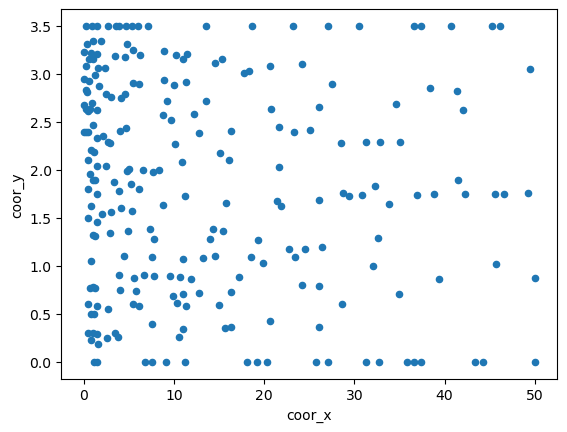

In [632]:
#see where the missing values are --> a bit everywhere, which doesn't help us much 
sensors_misval = train.loc[missing_idx, 'sensor'].unique()
sensors_misval_coords = sensors[sensors['sensor'].isin(sensors_misval)]

sensors_misval_coords.plot(kind='scatter', x='coor_x', y='coor_y')
plt.show()

In [633]:
#fills the missing temperature by using interpolate because our data is ordered chronologically 
#and taking into account ouly values from the same sensor
train['temperature'] = (
    train.groupby('sensor')['temperature']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

In [634]:
#control that every missing values are replaced
train.isna().any() 

sensor         False
time           False
power          False
temperature    False
dtype: bool

In [635]:
#finding the number of the two sensors which are very far from our expected values; outliers
neg_outlier = train[train['temperature'] == train['temperature'].min()]
pos_outlier = train[train['temperature'] == train['temperature'].max()]
print(neg_outlier['sensor'], pos_outlier['sensor'])

483784     N277
483785     N277
483786     N277
483787     N277
483788     N277
           ... 
4910859    N277
4910860    N277
4910861    N277
4910862    N277
4910863    N277
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96'] 2181592    N927
2181593    N927
2181594    N927
2181595    N927
2181596    N927
           ... 
6608667    N927
6608668    N927
6608669    N927
6608670    N927
6608671    N927
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96']


In [636]:
#get rid of the outlier sensors
train = train[train["sensor"] != "N277"]
train = train[train["sensor"] != "N927"]
sensors = sensors[sensors["sensor"] != "N277"]
sensors = sensors[sensors["sensor"] != "N927"]

In [637]:
#verify that the outlier sensors are gone
np.all(train["sensor"] != 'N277') and np.all(train["sensor"] != 'N927')

np.True_

In [638]:
#temperatures per sensors after getting rid of the two bad sensors
#train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15)

In [639]:
#we see there are duplicates in sensors
print(sensors['sensor'].duplicated().sum())  # y a-t-il des doublons ?
print(sensors.shape)
print(sensors['sensor'].nunique())

2
(323, 4)
321


In [640]:
#drop duplicates
sensors_unique = sensors.drop_duplicates(subset='sensor')

In [641]:
# merge the train dataframe with the sensors dataframe to get the coordinates of each sensor
train = train.merge(sensors_unique[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor', how='left')
#drop the coor_z column because it is not useful for our model and it is highly correlated with coor_x and coor_y
train = train.drop(columns=['coor_z'])

# merge the test dataframe with the sensors dataframe to get the coordinates of each sensor
test = test.merge(sensors_unique[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor', how='left')
#drop the coor_z column because it is not useful for our model and it is highly correlated with coor_x and coor_y
test = test.drop(columns=['coor_z'])

# control
print(train.columns)
test.head()

Index(['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y'], dtype='str')


,sensor,time,power,coor_x,coor_y
0,N104,864000.0,1487.288818,44.278809,3.5
1,N104,1728000.0,1486.612915,44.278809,3.5
2,N104,2592000.0,1485.936890,44.278809,3.5
3,N104,3456000.0,1485.260986,44.278809,3.5
4,N104,4320000.0,1484.585083,44.278809,3.5


In [642]:
# Normalisation of time and power
scaler = StandardScaler()
train[['time', 'power']] = scaler.fit_transform(train[['time', 'power']])

# Normalisation of coordinates
scaler_coords = StandardScaler()
train[['coor_x', 'coor_y']] = scaler_coords.fit_transform(
    train[['coor_x', 'coor_y']]
)

# Verification
print(train[['time', 'power', 'coor_x', 'coor_y']].describe())

               time         power        coor_x        coor_y
count  6.572160e+06  6.572160e+06  6.572160e+06  6.572160e+06
mean   7.306779e-17 -8.247803e-17  1.783090e-08 -5.824759e-08
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
min   -1.732045e+00 -1.055347e+00 -9.957756e-01 -1.666897e+00
25%   -8.657853e-01 -1.055347e+00 -8.403574e-01 -8.692871e-01
50%    1.327983e-04 -2.098822e-01 -3.490839e-01  5.826836e-03
75%    8.660130e-01  8.463630e-01  5.941306e-01  8.908014e-01
max    1.731931e+00  1.797218e+00  2.670097e+00  1.513439e+00


In [644]:
# Normalisation of time and power
scaler = StandardScaler()
test[['time', 'power']] = scaler.fit_transform(test[['time', 'power']])

# Normalisation of coordinates
scaler_coords = StandardScaler()
test[['coor_x', 'coor_y']] = scaler_coords.fit_transform(
    test[['coor_x', 'coor_y']]
)

# Verification
print(test[['time', 'power', 'coor_x', 'coor_y']].describe())

               time         power        coor_x        coor_y
count  2.190480e+06  2.190480e+06  2.190480e+06  2.190480e+06
mean  -1.909936e-17  4.691798e-17  4.458212e-08  2.496599e-08
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
min   -1.732045e+00 -1.055280e+00 -1.026388e+00 -1.454405e+00
25%   -8.659751e-01 -1.055280e+00 -8.565745e-01 -8.003416e-01
50%    1.328482e-04 -2.099418e-01 -2.168856e-01 -1.153435e-01
75%    8.662028e-01  8.465250e-01  5.098840e-01  8.950949e-01
max    1.731931e+00  1.797427e+00  2.736567e+00  1.525595e+00


(2190720, 6) (2190720, 6) (2190720, 6)


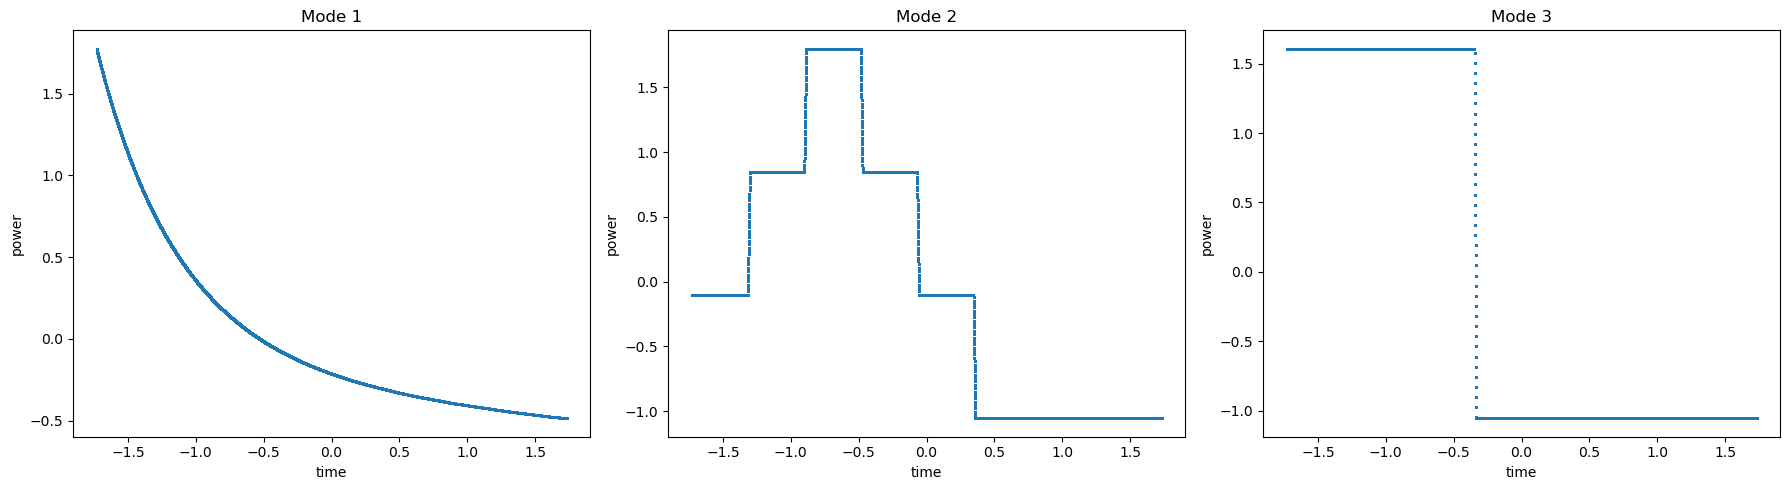

In [645]:
#separate out three modes so that we can try different models for different modes
BLOCK = len(train) // 3

mode1 = train.iloc[0       : BLOCK].copy()
mode2 = train.iloc[BLOCK   : 2*BLOCK].copy()
mode3 = train.iloc[2*BLOCK :].copy()

# Vérification
print(mode1.shape, mode2.shape, mode3.shape)

# Visualiser les 3 modes séparément
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

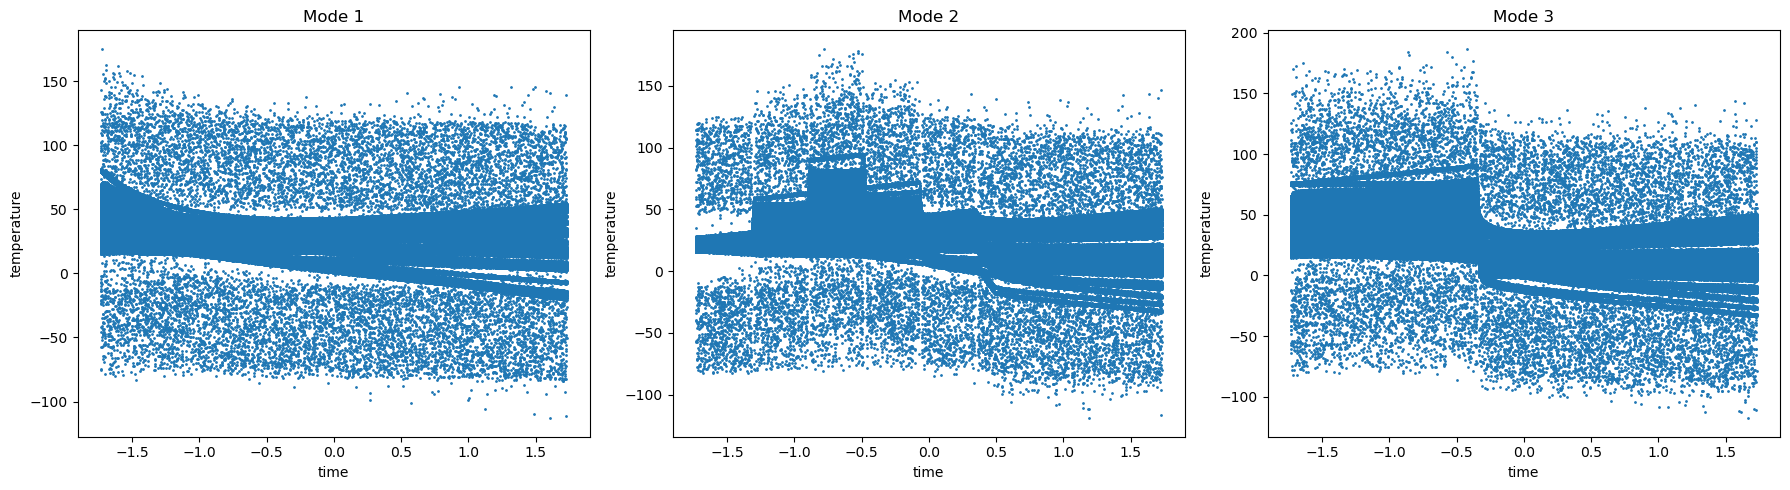

In [646]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='temperature', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

(730160, 5) (730160, 5) (730160, 5)


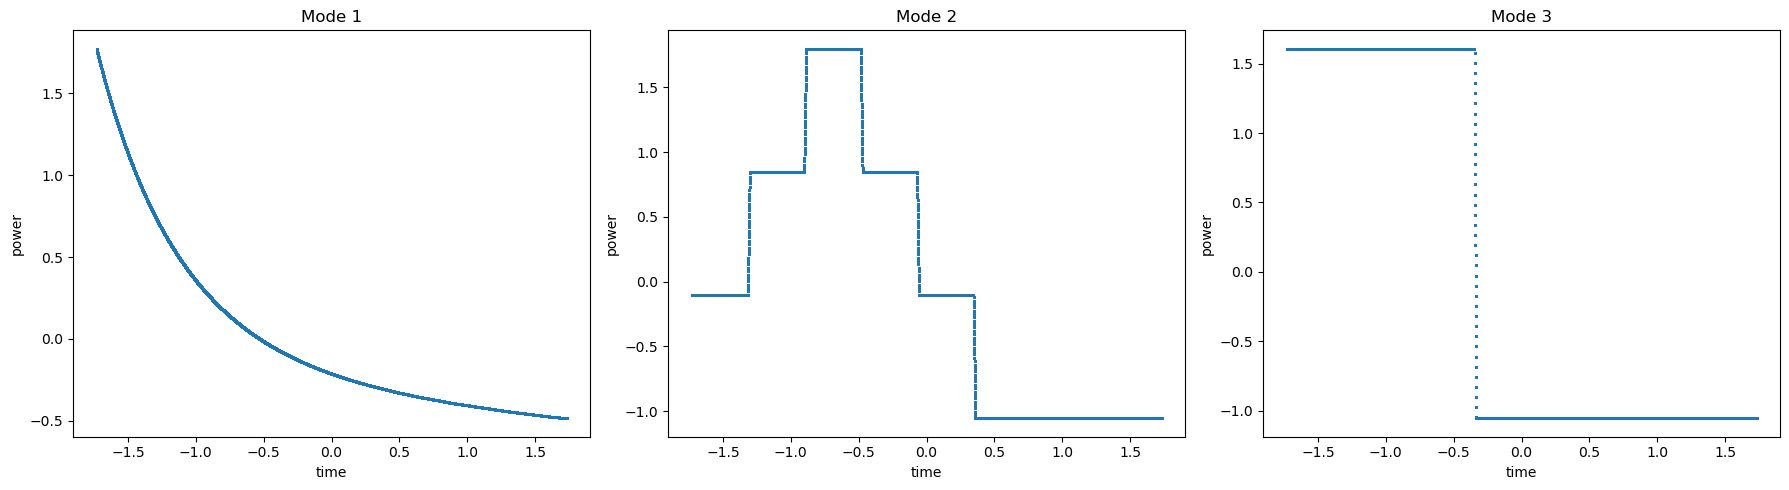

In [647]:
BLOCK = len(test) // 3

test_mode1 = test.iloc[0       : BLOCK].copy()
test_mode2 = test.iloc[BLOCK   : 2*BLOCK].copy()
test_mode3 = test.iloc[2*BLOCK :].copy()

# Vérification
print(test_mode1.shape, test_mode2.shape, test_mode3.shape)

# Visualiser les 3 modes séparément
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

test_mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
test_mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
test_mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

Outliers

In [648]:
random_sensor = train['sensor'].sample(1).values[0]
subset = train[train['sensor'] == random_sensor]
print(f"Sensor: {random_sensor}, shape: {subset.shape}")
print(subset.head())

Sensor: N259, shape: (27384, 6)
       sensor      time     power  temperature    coor_x    coor_y
419888   N259 -1.732045  1.774330    17.361208  0.201024  0.523197
419889   N259 -1.731666  1.773045    16.709385  0.201024  0.523197
419890   N259 -1.731286  1.771759    17.068672  0.201024  0.523197
419891   N259 -1.730906  1.770474    17.161322  0.201024  0.523197
419892   N259 -1.730527  1.769188    17.752522  0.201024  0.523197


<Axes: xlabel='time', ylabel='temperature'>

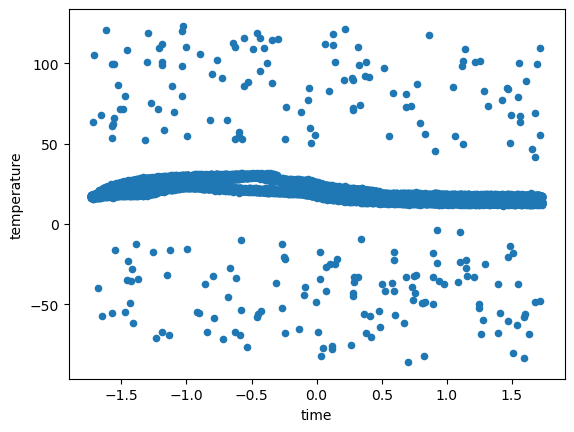

In [649]:
subset.plot(kind='scatter', x='time', y='temperature')

Before: 27384, After: 27140, Removed: 244


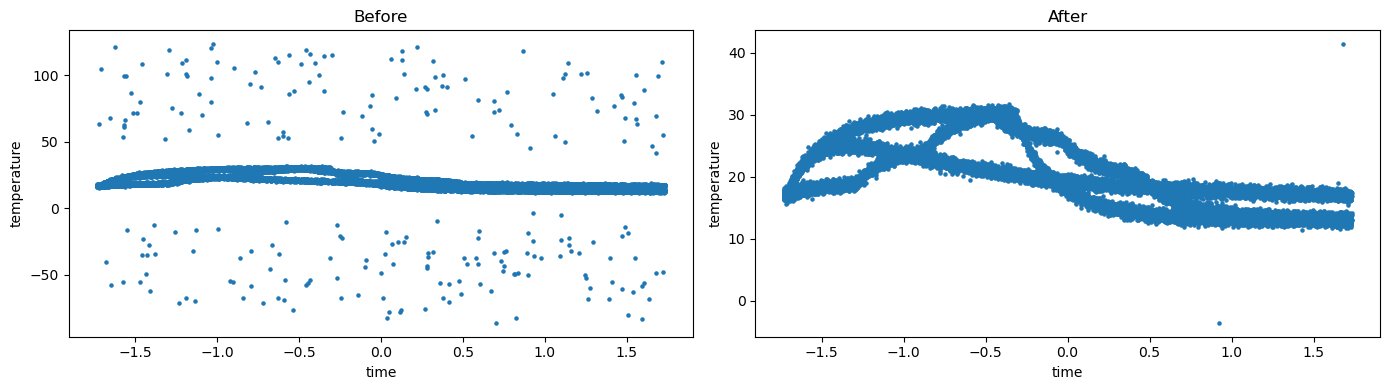

In [650]:
subset_clean = subset[np.abs(stats.zscore(subset['temperature'])) < 3]

print(f"Before: {len(subset)}, After: {len(subset_clean)}, Removed: {len(subset) - len(subset_clean)}")

# Plot to compare
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
subset.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Before', s=5)
subset_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='After', s=5)
plt.tight_layout()
plt.show()

In [688]:
def remove_outliers_mode1(df, threshold=3, column='temperature'):
    # Fit a polynomial on time → captures the smooth decay trend
    time = df['time'].to_numpy()
    temp = df[column].to_numpy()
    
    degree = 4
    coeffs = np.polyfit(time, temp, degree)
    trend = np.polyval(coeffs, time)
    
    # Compute residuals and remove points far from the fitted curve
    residuals = temp - trend
    mask = np.abs(stats.zscore(residuals)) < threshold
    
    return df[mask]


def remove_outliers_mode2(df, threshold=3, column='temperature'):
    # Step function mode → group by power level first, then remove outliers within each step
    power_levels = pd.cut(df['power'], bins=8)
    mask = (
        df.groupby(power_levels, observed=True)[column]
        .transform(lambda x: np.abs(stats.zscore(x, ddof=0)) < threshold if len(x) > 1 else True)
        .astype(bool)
    )
    return df[mask]


def remove_outliers_mode3(df, threshold=3, column='temperature'):
    # Two flat levels with sharp transition
    power_levels = pd.cut(df['power'], bins=2)
    mask = (
        df.groupby(power_levels, observed=True)[column]
        .transform(lambda x: np.abs(stats.zscore(x, ddof=0)) < threshold if len(x) > 1 else True)
        .astype(bool)
    )
    return df[mask]

OUTLIER_FN = {
    1: remove_outliers_mode1,
    2: remove_outliers_mode2,
    3: remove_outliers_mode3,
}

def clean_mode(mode_df, sensors_unique, mode_id, threshold=3):
    outlier_fn = OUTLIER_FN[mode_id]
    
    return (
        mode_df.merge(sensors_unique, on='sensor')
        .drop(columns=['coor_x_y', 'coor_y_y', 'coor_z'])
        .rename(columns={'coor_x_x': 'coor_x', 'coor_y_x': 'coor_y'})
        .groupby(['sensor', pd.qcut(range(len(mode_df)), q=3, labels=['t1', 't2', 't3'])])
        .apply(lambda df: outlier_fn(df, threshold), include_groups=False)
        .reset_index(level=[0, 1], drop=True) 
        .reset_index()
        .rename(columns={'index':'sensor'})
    )

mode1_clean = clean_mode(mode1, sensors_unique, mode_id=1)
mode2_clean = clean_mode(mode2, sensors_unique, mode_id=2)
mode3_clean = clean_mode(mode3, sensors_unique, mode_id=3)

train_clean = pd.concat([mode1_clean, mode2_clean, mode3_clean], ignore_index=True)

In [689]:
mode2_clean.head()

,sensor,time,power,temperature,coor_x,coor_y
0,0,-1.732045,-0.104492,17.536963,2.386466,1.513439
1,1,-1.731666,-0.104492,17.196196,2.386466,1.513439
2,2,-1.731286,-0.104492,17.359032,2.386466,1.513439
3,3,-1.730906,-0.104492,16.617247,2.386466,1.513439
4,4,-1.730527,-0.104492,16.811453,2.386466,1.513439


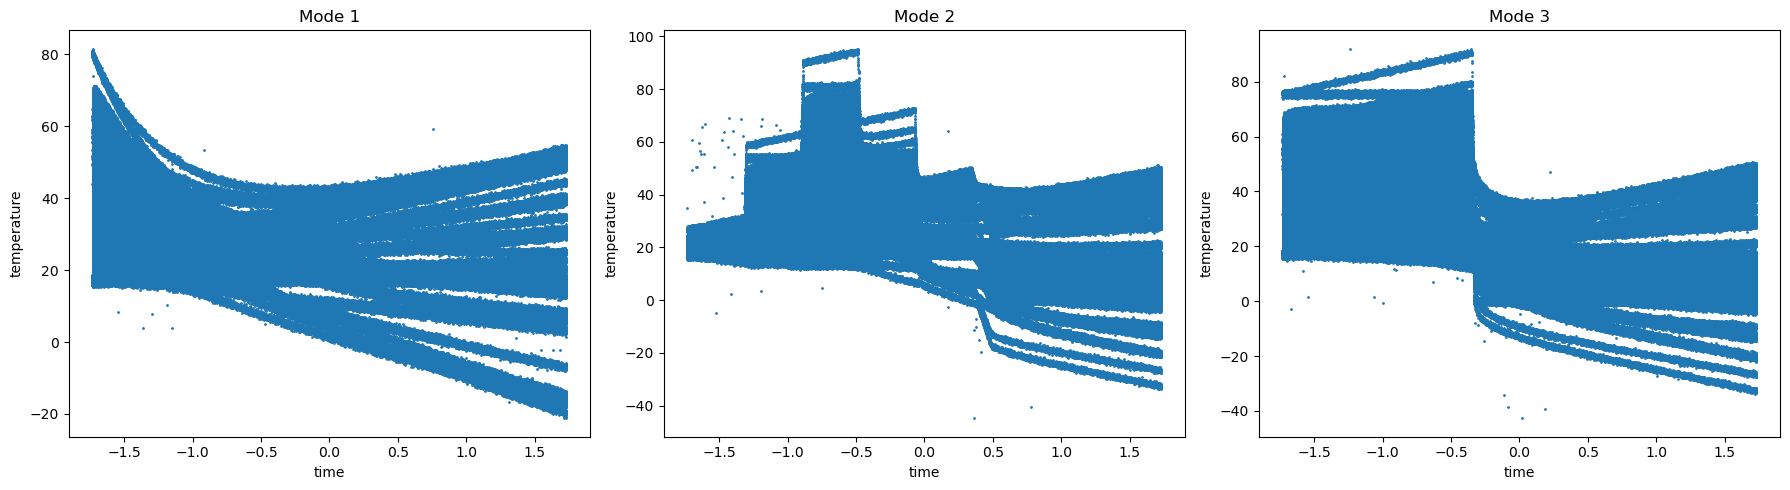

In [652]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Mode 1', s=1)
mode2_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='Mode 2', s=1)
mode3_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

KNN

In [653]:
#Transforms data into numpy arrays and splits it into a train, val and test set
def preprocess_data(
    df: pd.DataFrame,
    label: str,
    train_size: float = 0.6,
    val_size: float = 0.2,
    seed: Optional[int] = None,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    List[str],
]:
    df = df.sample(frac=1, random_state=seed)

    train, val, test = (
        df[: int(len(df) * train_size)],
        df[int(len(df) * train_size) : int(len(df) * (train_size + val_size))],
        df[int(len(df) * (train_size + val_size)) :],
    )

    X_train = train.drop(columns=label).to_numpy()
    X_val = val.drop(columns=label).to_numpy()
    X_test = test.drop(columns=label).to_numpy()

    y_train = train[label].to_numpy()
    y_val = val[label].to_numpy()
    y_test = test[label].to_numpy()

    return X_train, y_train, X_val, y_val, X_test, y_test

In [654]:
def predict(
    samples: np.ndarray, 
    X: np.ndarray,
    y: np.ndarray,
    k: int = 1):

    #find indices of k neighbors
    tree = KDTree(X)                    
    _, indices = tree.query(samples, k=k, workers=-1)
    
    if k == 1:
        return y[indices].flatten()
    return np.mean(y[indices], axis=1)

In [655]:
def rmse(
    labels_gt: np.ndarray,
    labels_pred: np.ndarray):

    rmse = np.sqrt(np.mean((labels_gt - labels_pred) ** 2))

    return rmse

In [667]:
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(df=train_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)

In [675]:
y_pred_train = predict(X_val, X_train, y_train, k=25)

In [676]:
#rmse for the prediction without sepatating our data by their powers
print(rmse(y_val, y_pred_train))

7.3792086


In [659]:
X_train1, y_train1, X_val1, y_val1, X_test1, y_test1 = preprocess_data(df=mode1_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)
X_train2, y_train2, X_val2, y_val2, X_test2, y_test2 = preprocess_data(df=mode2_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)
X_train3, y_train3, X_val3, y_val3, X_test3, y_test3 = preprocess_data(df=mode3_clean.drop(columns=['power']), label="temperature", train_size=0.6, val_size=0.2, seed=42)

In [660]:
y_pred_mode1 = predict(X_test1, X_train1, y_train1, k=25)
y_pred_mode2 = predict(X_test2, X_train2, y_train2, k=25)
y_pred_mode3 = predict(X_test3, X_train3, y_train3, k=25)

y_test_modes = np.concatenate([y_test1, y_test2, y_test3])
y_pred_modes = np.concatenate([y_pred_mode1, y_pred_mode2, y_pred_mode3])

In [661]:
print(rmse(y_test1, y_pred_mode1))
print(rmse(y_test2, y_pred_mode2))
print(rmse(y_test3, y_pred_mode3))

0.53398424
0.55207014
0.5745177


In [662]:
print(rmse(y_test_modes, y_pred_modes))

0.55374414


In [663]:
#trouver meilleur k
k_values = []
accs = []
for i in range(1, 50):
    acc = rmse(y_val1, predict(X_val1, X_train1, y_train1, k=i))
    k_values.append(i)
    accs.append(acc)

C:\Users\alice\AppData\Local\Temp\ipykernel_22756\1202109312.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


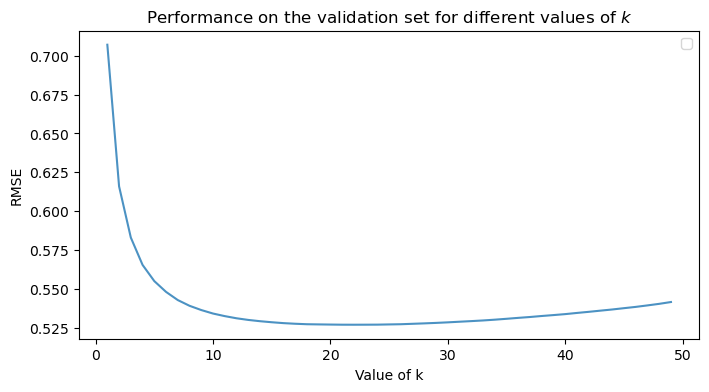

In [664]:
# Plot rmse in function of k
plt.figure(figsize=(8,4), dpi=100)
plt.plot(k_values, accs, alpha=0.8)
plt.xlabel("Value of k")
plt.ylabel("RMSE")
plt.legend()
plt.title("Performance on the validation set for different values of $k$")
plt.show()

we can that the bigger the k, the best the rmse is, so we will take k = 25. 

In [706]:
test1 = test_mode1.drop(columns=['power', 'sensor']).to_numpy()
test2 = test_mode2.drop(columns=['power', 'sensor']).to_numpy()
test3 = test_mode3.drop(columns=['power', 'sensor']).to_numpy()

X_mode1 = mode1_clean.drop(columns=['power', 'sensor', 'temperature']).to_numpy()
X_mode2 = mode2_clean.drop(columns=['power', 'sensor', 'temperature']).to_numpy()
X_mode3 = mode3_clean.drop(columns=['power', 'sensor', 'temperature']).to_numpy()

y_mode1 = mode1_clean['temperature'].to_numpy()
y_mode2 = mode2_clean['temperature'].to_numpy()
y_mode3 = mode3_clean['temperature'].to_numpy()

In [707]:
y_pred_mode1 = predict(test1, X_mode1, y_mode1, k=25)
y_pred_mode2 = predict(test2, X_mode2, y_mode2, k=25)
y_pred_mode3 = predict(test3, X_mode3, y_mode3, k=25)

y_pred = np.concatenate([y_pred_mode1, y_pred_mode2, y_pred_mode3])

In [708]:
print(f"Number of final predictions: {len(y_pred)}")

Number of final predictions: 2190480


In [709]:
submission = pd.DataFrame({
   "Id": np.arange(len(test), dtype=int),
   "temperature": y_pred,
})
assert list(submission.columns) == ["Id", "temperature"]
assert len(submission) == len(test)
assert (submission["Id"].to_numpy() == np.arange(len(test))).all()
assert np.isfinite(submission["temperature"]).all()
assert submission.isna().sum().sum() == 0
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")

Saved submission.csv
